<a href="https://colab.research.google.com/github/karenMartinezGeo/introduction-to-github/blob/main/prueba_piloto_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [6]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel(list(uploaded.keys())[0])


Saving prueba piloto.xlsx to prueba piloto (3).xlsx


In [10]:
df.head()
df.info()

# quitar espacios raros en encabezados
df.columns = df.columns.str.strip()

# asegurar tipos numéricos
df["INYECTION"] = pd.to_numeric(df["INYECTION"], errors="coerce")
df["ESPESOR_FT"] = pd.to_numeric(df["ESPESOR_FT"], errors="coerce")
df["FACIE"] = pd.to_numeric(df["FACIE"], errors="coerce")
df["COMPORTAMIENTO_TIEMPO"] = pd.to_numeric(df["COMPORTAMIENTO_TIEMPO"], errors="coerce")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   WELL                   374 non-null    object 
 1   MANDREL                374 non-null    int64  
 2   INTERVAL               374 non-null    int64  
 3   TOP_FT                 374 non-null    int64  
 4   BOTTOM_FT              374 non-null    int64  
 5   SAND_NAME              374 non-null    object 
 6   SAND_UNIT              374 non-null    object 
 7   TYPE_ROCK              374 non-null    object 
 8   FACIE                  374 non-null    int64  
 9   BOOLEAN                354 non-null    float64
 10  INYECTION              374 non-null    int64  
 11  COMPORTAMIENTO_TIEMPO  31 non-null     float64
 12  AREA                   374 non-null    object 
 13  ESPESOR_FT             374 non-null    int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 41.0+ KB


In [14]:
# Facie en texto
facie_map = {0: "Canal", 1: "Crevasse", 2: "Flood"}
df["Facie_txt"] = df["FACIE"].map(facie_map)

# Inyección en texto
df["Inyection_txt"] = df["INYECTION"].map({1: "Inyecta", 0: "No inyecta"})

# Dejó de tomar (para análisis)
df["DEJO_TOMAR"] = df["COMPORTAMIENTO_TIEMPO"].fillna(0)

# Rangos de espesor
def rango(x):
    if pd.isna(x): return None
    if x < 10: return "Delgado"
    elif x < 20: return "Medio"
    else: return "Grueso"

df["Rango_espesor"] = df["ESPESOR_FT"].apply(rango)

df[["Facie_txt","INYECTION","ESPESOR_FT","Rango_espesor"]].head()

,Facie_txt,INYECTION,ESPESOR_FT,Rango_espesor
0,Canal,1,10,Medio
1,Canal,0,9,Delgado
2,Crevasse,0,6,Delgado
3,Canal,1,3,Delgado
4,Crevasse,0,6,Delgado


In [15]:
#GRAFICAS

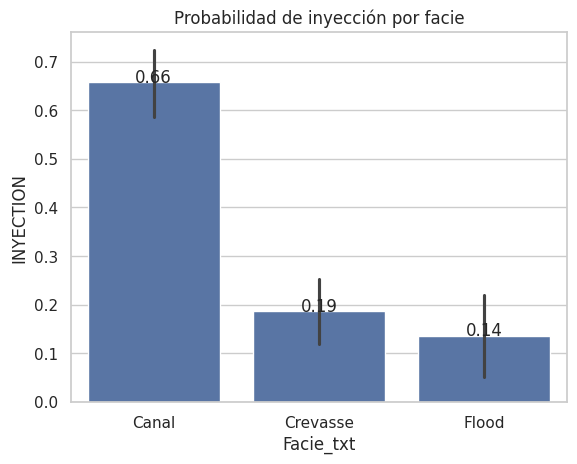

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

ax = sns.barplot(data=df, x="Facie_txt", y="INYECTION", estimator=np.mean)

# Agregar labels
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,
            height,
            f'{height:.2f}',
            ha="center")

plt.title("Probabilidad de inyección por facie")
plt.show()


In [21]:
!pip install plotly
import plotly.express as px

In [23]:
df_avg = df.groupby("Facie_txt")["INYECTION"].mean().reset_index()

fig = px.bar(
    df_avg,
    x="Facie_txt",
    y="INYECTION",
    color="Facie_txt",
    text_auto=".2f",
    title="Probabilidad de inyección por facie"
)

fig.show()


In [25]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Facie_txt",
    color="Inyection_txt",
    barmode="group",  # barras lado a lado
    text_auto=True,
    title="Cantidad de intervalos que inyectan vs no inyectan por facie"
)

fig.show()

In [26]:
fig = px.histogram(
    df,
    x="Facie_txt",
    color="Inyection_txt",
    facet_col="TYPE_ROCK",  # opcional
    barmode="group",
    title="Inyección por facie y tipo de roca"
)

fig.show()

In [30]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Facie_txt",
    color="Inyection_txt",
    barmode="stack",
    barnorm="percent",
    text_auto=".2f",
    title="Proporción de inyección por facie (%)"
)

fig.show()


In [31]:
fig = px.histogram(
    df,
    x="TYPE_ROCK",
    color="Inyection_txt",
    barmode="stack",
    barnorm="percent",   # convierte a %
    text_auto=".1f",
    title="Proporción de inyección por tipo de roca (%)"
)

fig.update_layout(xaxis_title="Tipo de roca", yaxis_title="% dentro de cada tipo de roca")
fig.show()

In [35]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Facie_txt",
    color="TYPE_ROCK",
    barmode="group",   # barras lado a lado
    text_auto=True,
    title="Cantidad de intervalos por facie y tipo de roca"
)

fig.show()

In [41]:
df_combo = df.groupby(["Facie_txt", "TYPE_ROCK"])["INYECTION"].mean().reset_index()

fig = px.bar(
    df_combo,
    x="Facie_txt",
    y="INYECTION",
    color="TYPE_ROCK",
    barmode="group",
    text_auto=".2f",
    title="Inyección por facie y tipo de roca"
)

fig.show()

In [43]:
df_canal = df[df["Facie_txt"] == "Canal"]
fig = px.histogram(
    df_canal,
    x="TYPE_ROCK",
    color="Inyection_txt",
    barmode="group",
    title="Cantidad de intervalos (Canal) por tipo de roca e inyección"
)

fig.show()

In [46]:

fig.write_html("grafico_interactivo.html")